In [1]:
#First let's import som useful things
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
from tabulate import tabulate
import statsmodels.api as sm
from statsmodels.formula.api import ols
import itertools
from itertools import combinations
from sklearn.decomposition import PCA
import seaborn as sns
from scipy.stats import shapiro, ttest_ind, kstest, norm
from plotly.subplots import make_subplots
import networkx as nx

In this notebook i will analyze dataset containing data about students performance in exams. In the data i have information about scores from math, reading and writing score (I will also immadietely calculate average score) and 'parameters' of each student which include gender, race/ethnicity, parental level of education, type of lunch eaten and whether the student completed test preparation course. So what are my goals?
1) I will try to find what's an impact of parameters on student score and how do interactions betweem them look? For that I will use ANOVA, t-tests and two-way ANOVA. Also I would use Kołmogorow-Smirnow test for checking normality of data if n>50 and Shapiro-Wilk in other case.
2) The second aim is to understand the distribution of scores in context of our parameters. As our data is 3D I will use PCA because it offers easy geometric intuition. In this context I would like to explain the shape of our data (by explaining sources of variance in each direction). 

In [4]:
#Importing dataset and adding average score label
df=pd.read_csv('exams.csv')
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,male,group A,high school,standard,completed,67,67,63,65.666667
1,female,group D,some high school,free/reduced,none,40,59,55,51.333333
2,male,group E,some college,free/reduced,none,59,60,50,56.333333
3,male,group B,high school,standard,none,77,78,68,74.333333
4,male,group E,associate's degree,standard,completed,78,73,68,73.000000


To get intuition I will try to visualize my data

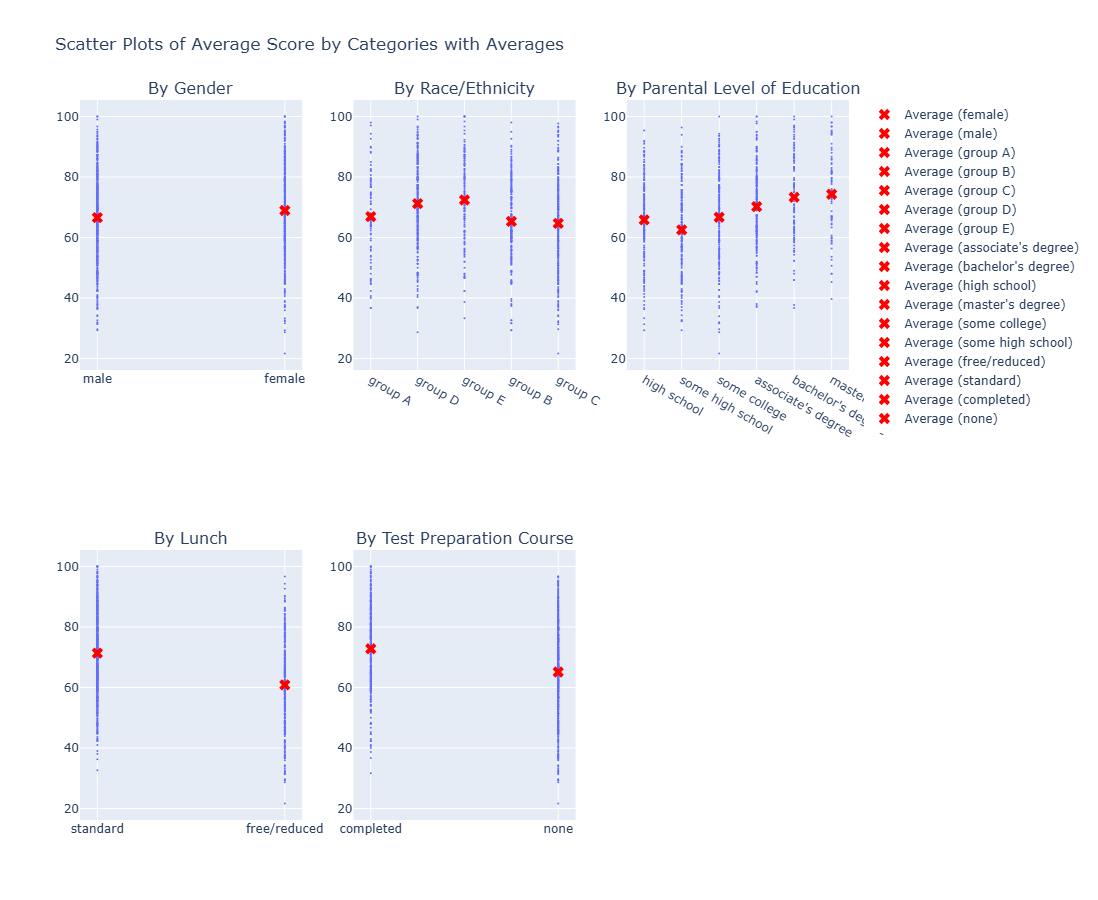

In [10]:
# Trying to visualize our data
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'By Gender', 
        'By Race/Ethnicity', 
        'By Parental Level of Education', 
        'By Lunch', 
        'By Test Preparation Course'
    ),
    specs=[[{'type': 'scatter'}, {'type': 'scatter'}, {'type': 'scatter'}],
           [{'type': 'scatter'}, {'type': 'scatter'}, {'type': 'scatter'}]]
)

# Plot 1: By Gender
fig1 = px.scatter(
    df,
    x='gender',
    y='average score',
    title='Average Score by Gender',
    labels={'gender': 'Gender', 'average score': 'Average Score'}
)
# Calculate average score for each gender
avg_gender = df.groupby('gender')['average score'].mean().reset_index()
for trace in fig1.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=1, col=1)

for gender, avg_score in zip(avg_gender['gender'], avg_gender['average score']):
    fig.add_trace(go.Scatter(
        x=[gender], y=[avg_score],
        mode='markers',
        marker=dict(size=10, color='red', symbol='x'),
        name=f'Average ({gender})'
    ), row=1, col=1)

# Plot 2: By Race/Ethnicity
fig2 = px.scatter(
    df,
    x='race/ethnicity',
    y='average score',
    title='Average Score by Race/Ethnicity',
    labels={'race/ethnicity': 'Race/Ethnicity', 'average score': 'Average Score'}
)
# Calculate average score for each race/ethnicity
avg_race = df.groupby('race/ethnicity')['average score'].mean().reset_index()
# Add average points to the plot
for trace in fig2.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=1, col=2)

for race, avg_score in zip(avg_race['race/ethnicity'], avg_race['average score']):
    fig.add_trace(go.Scatter(
        x=[race], y=[avg_score],
        mode='markers',
        marker=dict(size=10, color='red', symbol='x'),
        name=f'Average ({race})'
    ), row=1, col=2)

# Plot 3: By Parental Level of Education
fig3 = px.scatter(
    df,
    x='parental level of education',
    y='average score',
    title='Average Score by Parental Level of Education',
    labels={'parental level of education': 'Parental Level of Education', 'average score': 'Average Score'}
)
# Calculate average score for each parental level of education
avg_parental = df.groupby('parental level of education')['average score'].mean().reset_index()
# Add average points to the plot
for trace in fig3.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=1, col=3)

for parental, avg_score in zip(avg_parental['parental level of education'], avg_parental['average score']):
    fig.add_trace(go.Scatter(
        x=[parental], y=[avg_score],
        mode='markers',
        marker=dict(size=10, color='red', symbol='x'),
        name=f'Average ({parental})'
    ), row=1, col=3)

# Plot 4: By Lunch
fig4 = px.scatter(
    df,
    x='lunch',
    y='average score',
    title='Average Score by Lunch',
    labels={'lunch': 'Lunch', 'average score': 'Average Score'}
)
# Calculate average score for each lunch category
avg_lunch = df.groupby('lunch')['average score'].mean().reset_index()
# Add average points to the plot
for trace in fig4.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=2, col=1)

for lunch, avg_score in zip(avg_lunch['lunch'], avg_lunch['average score']):
    fig.add_trace(go.Scatter(
        x=[lunch], y=[avg_score],
        mode='markers',
        marker=dict(size=10, color='red', symbol='x'),
        name=f'Average ({lunch})'
    ), row=2, col=1)

# Plot 5: By Test Preparation Course
fig5 = px.scatter(
    df,
    x='test preparation course',
    y='average score',
    title='Average Score by Test Preparation Course',
    labels={'test preparation course': 'Test Preparation Course', 'average score': 'Average Score'}
)
# Calculate average score for each test preparation course
avg_test_preparation = df.groupby('test preparation course')['average score'].mean().reset_index()
# Add average points to the plot
for trace in fig5.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=2, col=2)

for course, avg_score in zip(avg_test_preparation['test preparation course'], avg_test_preparation['average score']):
    fig.add_trace(go.Scatter(
        x=[course], y=[avg_score],
        mode='markers',
        marker=dict(size=10, color='red', symbol='x'),
        name=f'Average ({course})'
    ), row=2, col=2)

#Final works
fig.update_layout(
    height=900,
    width=1200,
    title_text="Scatter Plots of Average Score by Categories with Averages",
    showlegend=True
)

fig.show()


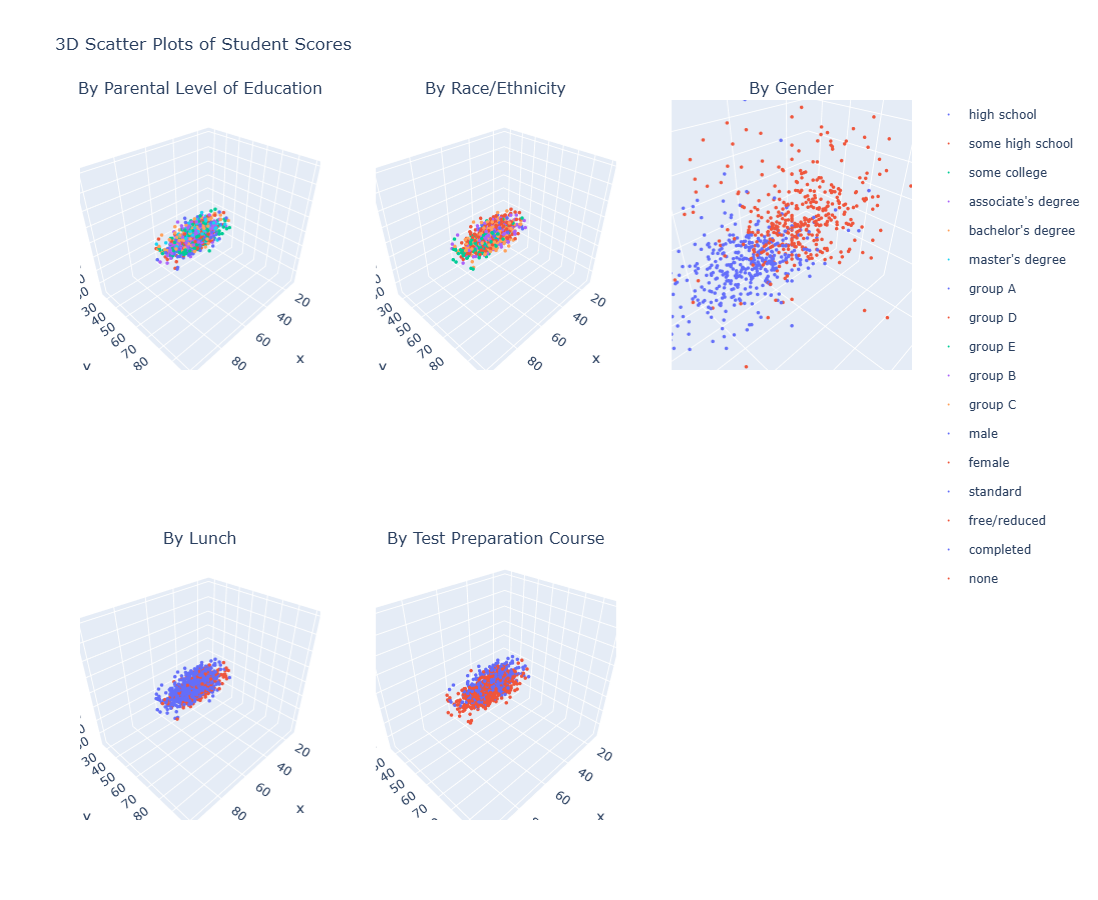

In [146]:
#Again I will try to make more insightful visualisations
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'By Parental Level of Education', 
        'By Race/Ethnicity', 
        'By Gender', 
        'By Lunch', 
        'By Test Preparation Course'
    ),
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}, {'type': 'scatter3d'}],
           [{'type': 'scatter3d'}, {'type': 'scatter3d'}, {'type': 'scatter3d'}]]
)

# Plot 1: By Parental Level of Education
fig1 = px.scatter_3d(
    df,
    x='math score',
    y='reading score',
    z='writing score',
    color='parental level of education',
    title='3D Scatter Plot of Student Scores',
    labels={
        'math score': 'Math Score',
        'reading score': 'Reading Score',
        'writing score': 'Writing Score'
    }
)
# Add traces from fig1 to the subplot and set marker size to 2
for trace in fig1.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=1, col=1)

# Plot 2: By Race/Ethnicity
fig2 = px.scatter_3d(
    df,
    x='math score',
    y='reading score',
    z='writing score',
    color='race/ethnicity',
    title='3D Scatter Plot of Student Scores',
    labels={
        'math score': 'Math Score',
        'reading score': 'Reading Score',
        'writing score': 'Writing Score'
    }
)
# Add traces from fig2 to the subplot and set marker size to 2
for trace in fig2.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=1, col=2)

# Plot 3: By Gender
fig3 = px.scatter_3d(
    df,
    x='math score',
    y='reading score',
    z='writing score',
    color='gender',
    title='3D Scatter Plot of Student Scores',
    labels={
        'math score': 'Math Score',
        'reading score': 'Reading Score',
        'writing score': 'Writing Score'
    }
)
# Add traces from fig3 to the subplot and set marker size to 2
for trace in fig3.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=1, col=3)

# Plot 4: By Lunch
fig4 = px.scatter_3d(
    df,
    x='math score',
    y='reading score',
    z='writing score',
    color='lunch',
    title='3D Scatter Plot of Student Scores',
    labels={
        'math score': 'Math Score',
        'reading score': 'Reading Score',
        'writing score': 'Writing Score'
    }
)
# Add traces from fig4 to the subplot and set marker size to 2
for trace in fig4.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=2, col=1)

# Plot 5: By Test Preparation Course
fig5 = px.scatter_3d(
    df,
    x='math score',
    y='reading score',
    z='writing score',
    color='test preparation course',
    title='3D Scatter Plot of Student Scores',
    labels={
        'math score': 'Math Score',
        'reading score': 'Reading Score',
        'writing score': 'Writing Score'
    }
)
# Add traces from fig5 to the subplot and set marker size to 2
for trace in fig5.data:
    fig.add_trace(trace.update(marker=dict(size=2)), row=2, col=2)

# Update layout
fig.update_layout(
    height=900,
    width=1200,
    title_text="3D Scatter Plots of Student Scores",
    showlegend=True
)

fig.show()


What do we see in the charts? There is definitely a strong linear correlation between the scores in individual subjects. This is not surprising. We can also see differences between specific groups. What particularly stands out in the 3D plot is the difference between genders.

Now, I think it's time for histograms.

array([[<Axes: title={'center': 'math score'}>,
        <Axes: title={'center': 'reading score'}>],
       [<Axes: title={'center': 'writing score'}>,
        <Axes: title={'center': 'average score'}>]], dtype=object)

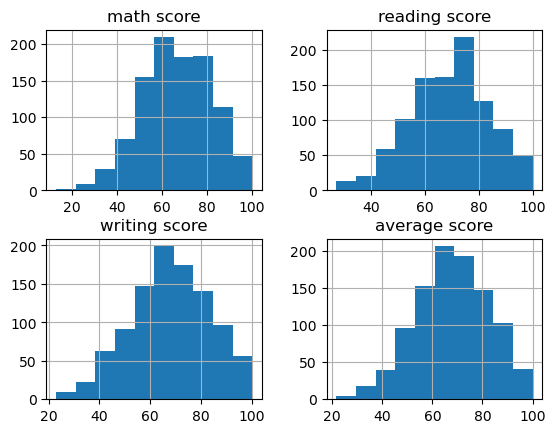

In [11]:
df.hist()

Nothing extraordinary here.
Now let's start with simple one way ANOVA to see whether impact of parameters is significant

In [32]:
def anova(df,name,alpha):
    groups=[[],[],[],[],[]]
    data=[]
    i=0
    print('In context of ' + name + ":")
    for c in df.iloc[:,:5].columns:
        for item in df[c].unique():
            groups[i].append(df[df[c]==item][name].to_list())
        i=i+1
    for i in range(0,len(groups)):
        f_statistic, p_value = stats.f_oneway(*groups[i])
        grand_mean = np.concatenate(groups[i]).mean()
        group_means = [np.array(group).mean() for group in groups[i]]
        ss_between = sum(len(group) * (np.array(group).mean() - grand_mean) ** 2 for group in groups[i])
        ss_total = sum((x - grand_mean) ** 2 for x in np.concatenate(groups[i]))
        ss_within = ss_total - ss_between  # Residual sum of squares
        eta_squared = ss_between / ss_total
        if p_value < alpha:
            significance="yes"
        else:
            significance="no"
        data.append([df.iloc[:,:5].columns[i],p_value,eta_squared,ss_between,significance])
        headers=['parameter', 'p_value', 'η²','SSB','is significant?']
    print(tabulate(data,headers,tablefmt="grid"))
    return data
data_avg=anova(df,'average score',0.05)


In context of average score:
+-----------------------------+-------------+-----------+----------+-------------------+
| parameter                   |     p_value |        η² |      SSB | is significant?   |
+=============================+=============+===========+==========+===================+
| gender                      | 0.0101887   | 0.0065963 |  1388.21 | yes               |
+-----------------------------+-------------+-----------+----------+-------------------+
| race/ethnicity              | 4.052e-10   | 0.0487328 | 10255.9  | yes               |
+-----------------------------+-------------+-----------+----------+-------------------+
| parental level of education | 2.95714e-13 | 0.0658273 | 13853.5  | yes               |
+-----------------------------+-------------+-----------+----------+-------------------+
| lunch                       | 3.18403e-29 | 0.118602  | 24960    | yes               |
+-----------------------------+-------------+-----------+----------+-------------

The η² coefficient corresponds to SSB divided by SST, so it describes how much of the variance is explained by the individual parameters. It turns out that the biggest influence on the average exam score is having lunch, which confirms the intuition from the previous plots. This type of analysis can be repeated for each of the individual exams.

In [34]:
data_math=anova(df,'math score',0.05)
data_read=anova(df,'reading score',0.05)
data_write=anova(df,'writing score',0.05)

In context of math score:
+-----------------------------+-------------+-----------+----------+-------------------+
| parameter                   |     p_value |        η² |      SSB | is significant?   |
+=============================+=============+===========+==========+===================+
| gender                      | 1.4615e-10  | 0.0403461 |  9562.47 | yes               |
+-----------------------------+-------------+-----------+----------+-------------------+
| race/ethnicity              | 1.19429e-14 | 0.0691039 | 16378.4  | yes               |
+-----------------------------+-------------+-----------+----------+-------------------+
| parental level of education | 2.40033e-11 | 0.057137  | 13542.1  | yes               |
+-----------------------------+-------------+-----------+----------+-------------------+
| lunch                       | 1.23273e-34 | 0.140199  | 33228.7  | yes               |
+-----------------------------+-------------+-----------+----------+----------------

([<matplotlib.axis.XTick at 0x218360549b0>,
 [Text(0, 0, 'Gender'),
  Text(1, 0, 'Race'),
  Text(2, 0, 'Parental education'),
  Text(3, 0, 'Lunch'),
  Text(4, 0, 'Preparation course')])

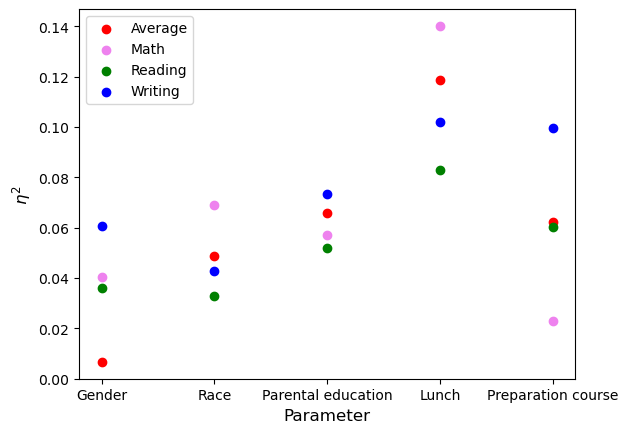

In [36]:
#Let's visualize it on some kind of plot!
for i in range(0,5):
    plt.scatter([i],[data_avg[i][2]], c='red')
    plt.scatter([i],[data_math[i][2]], c='violet')
    plt.scatter([i],[data_read[i][2]], c='green')
    plt.scatter([i],[data_write[i][2]], c='blue')
plt.ylabel(r'$\eta^2$', fontsize=12);
plt.xlabel('Parameter', fontsize=12);
plt.legend(['Average', 'Math', 'Reading', 'Writing'], loc='upper left');
plt.xticks([0, 1, 2, 3, 4], ['Gender','Race','Parental education', 'Lunch', 'Preparation course'])

It looks like eating lunch is very important for academic success! I will take note of that!

From that analysis I can conclude that for math exam the best thing a student can do is each proper lunch. However reaching that conclusion is in my opinion naive. In my data i have limited options for exploring how material situation of students impact their performance on exams. Because of that i cannot test if there is an interaction between eating standard/free/reduced lunch and financial factors. I would argue here that there is a important correlation between type of lunch the students are eating and their family wealth. And the family wealth seems to be a far imporant factor than eating habits. Because of that, I don't think that we can reach a decisivie conclusion that better launch *causes* the increase in grades. It *correlates* with it for sure and we see it in our data. It is also pretty clear that preparation course seems to be less important for math performance than for other subjects. 
In context of reading it is worth to note that preparation course seems to be quite useful, and 'eating good lunch' again seems important. 
In context if writing it seem that preparation course is very useful.

Now i want to conduct two way anova to look for interactions betweem my parameters

In [40]:
#Working with python libraries can be challenging, here i have to remove spaces because library doesn't like them
df.rename(columns={'average score': 'average_score'}, inplace=True)
df.rename(columns={'math score': 'math_score'}, inplace=True)
df.rename(columns={'reading score': 'reading_score'}, inplace=True)
df.rename(columns={'writing score': 'writing_score'}, inplace=True)
df.rename(columns={'race/ethnicity': 'race'}, inplace=True)
df.rename(columns={'parental level of education': 'parental_education'}, inplace=True)
df.rename(columns={'test preparation course': 'course'}, inplace=True)
df.head()

,gender,race,parental_education,lunch,course,math_score,reading_score,writing_score,average_score
0,male,group A,high school,standard,completed,67,67,63,65.666667
1,female,group D,some high school,free/reduced,none,40,59,55,51.333333
2,male,group E,some college,free/reduced,none,59,60,50,56.333333
3,male,group B,high school,standard,none,77,78,68,74.333333
4,male,group E,associate's degree,standard,completed,78,73,68,73.000000


In [42]:
def check_interaction(df, factor1, factor2, dependent_variable, alpha=0.05):
    formula = f"{dependent_variable} ~ C({factor1}) + C({factor2}) + C({factor1}):C({factor2})"
    model = ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    try:
        p_value_interaction = anova_table.loc[f'C({factor1}):C({factor2})','PR(>F)']
        if p_value_interaction <alpha:
            return 1
        else:
            return 0
    except KeyError:
        return 0
#to 5 beacuse thats my parameters
factors = df.iloc[:, :5].columns.to_list()

interaction_matrix = pd.DataFrame(0, index=factors, columns=factors)
dependent_variable='average_score'

alpha = 0.05 #Significance level

# Loop through all combinations of factor pairs
for factor1, factor2 in itertools.combinations(factors, 2):
    if check_interaction(df, factor1, factor2, dependent_variable, alpha=alpha)==1:
        interaction_matrix.loc[factor1, factor2] = 1
        interaction_matrix.loc[factor2, factor1] = 1  # Symmetric matrix

print(interaction_matrix)

                    gender  race  parental_education  lunch  course
gender                   0     0                   0      0       0
race                     0     0                   0      0       0
parental_education       0     0                   0      0       0
lunch                    0     0                   0      0       0
course                   0     0                   0      0       0


Two way ANOVA doesn't detect any interactions between parameters. It might be a little suprising but it is what it is! Now let's test what are the correlations inside each groups. For that I will visualize all data on histograms (I aknowledge that some of them seems pointless as they are really crowded) and I will run t-tests to check which groups distributions are statistically different. To test for normality I will use Kołmogorow-Smirnow or Shapiro-Wilk depending on number of datapoints in each sample.
Statistical Independence Matrix is just a table with 'yes' if groups are statistically different and no if they are not.

In [102]:
def plot_multiple_grouped_distributions(df, names_parameter_column, name_data_column, alpha=0.05):
    num_parameters = len(names_parameter_column)

    # Create subplots (1 row, multiple columns)
    fig, axes = plt.subplots(nrows=1, ncols=num_parameters, figsize=(6 * num_parameters, 5), sharex=True, sharey=True)

    # Ensure axes is iterable when there's only one parameter
    if num_parameters == 1:
        axes = [axes]

    for ax, parameter in zip(axes, names_parameter_column):
        unique_groups = df[parameter].unique()
        palette = sns.color_palette("husl", len(unique_groups))

        # Store labels for legend
        for color, group in zip(palette, unique_groups):
            subset = df[df[parameter] == group][name_data_column]
            n = len(subset)

            # Select test based on sample size
            if n < 50:
                stat, p_value = shapiro(subset)
                test_used = "SW"
            else:
                stat, p_value = kstest(subset, 'norm', args=(subset.mean(), subset.std()))
                test_used = "KS"

            p_value_text = f"{group} ({test_used} p={p_value:.3f})"

            # Histogram with KDE (No Black Edges)
            sns.histplot(subset, ax=ax, bins=20, kde=True, stat="density", alpha=0.3, color=color, edgecolor="white")
            ax.plot([], [], color=color, label=p_value_text)

        # If more than two groups, perform pairwise t-tests
        if len(unique_groups) > 1:
            group_pairs = list(combinations(unique_groups, 2))
            
            # Create a matrix for pairwise statistical independence
            independence_matrix = pd.DataFrame(index=unique_groups, columns=unique_groups, data="")

            for group1, group2 in group_pairs:
                data1 = df[df[parameter] == group1][name_data_column]
                data2 = df[df[parameter] == group2][name_data_column]
                
                _, p_value = ttest_ind(data1, data2, equal_var=False)  # Welch’s t-test
                independent = "Yes" if p_value > alpha else "No"
                
                # Fill matrix symmetrically
                independence_matrix.loc[group1, group2] = independent
                independence_matrix.loc[group2, group1] = independent

            # Fill diagonal with 'Yes' (same groups are always identical)
            np.fill_diagonal(independence_matrix.values, "Yes")

            print(f"\nStatistical Independence Matrix for {parameter}:")
            print(tabulate(independence_matrix, headers="keys", tablefmt="grid"))

        # Titles and labels
        ax.set_title(f"Density of {name_data_column} by {parameter}")
        ax.set_xlabel(name_data_column)
        ax.set_ylabel("Density")
        ax.legend()

    plt.tight_layout()
    plt.show()


Statistical Independence Matrix for gender:
+--------+--------+----------+
|        | male   | female   |
+========+========+==========+
| male   | Yes    | No       |
+--------+--------+----------+
| female | No     | Yes      |
+--------+--------+----------+

Statistical Independence Matrix for lunch:
+--------------+------------+----------------+
|              | standard   | free/reduced   |
+==============+============+================+
| standard     | Yes        | No             |
+--------------+------------+----------------+
| free/reduced | No         | Yes            |
+--------------+------------+----------------+

Statistical Independence Matrix for course:
+-----------+-------------+--------+
|           | completed   | none   |
+===========+=============+========+
| completed | Yes         | No     |
+-----------+-------------+--------+
| none      | No          | Yes    |
+-----------+-------------+--------+


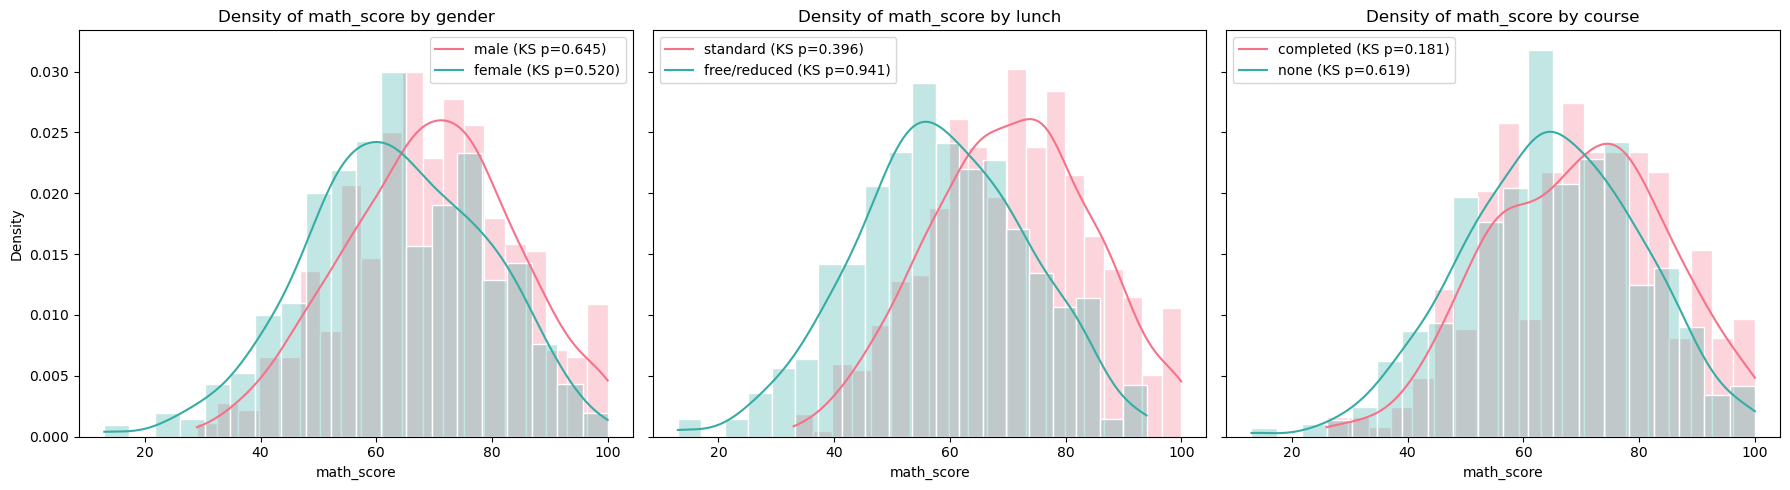


Statistical Independence Matrix for parental_education:
+--------------------+---------------+--------------------+----------------+----------------------+---------------------+-------------------+
|                    | high school   | some high school   | some college   | associate's degree   | bachelor's degree   | master's degree   |
+====================+===============+====================+================+======================+=====================+===================+
| high school        | Yes           | No                 | Yes            | No                   | No                  | No                |
+--------------------+---------------+--------------------+----------------+----------------------+---------------------+-------------------+
| some high school   | No            | Yes                | No             | No                   | No                  | No                |
+--------------------+---------------+--------------------+----------------+---------------

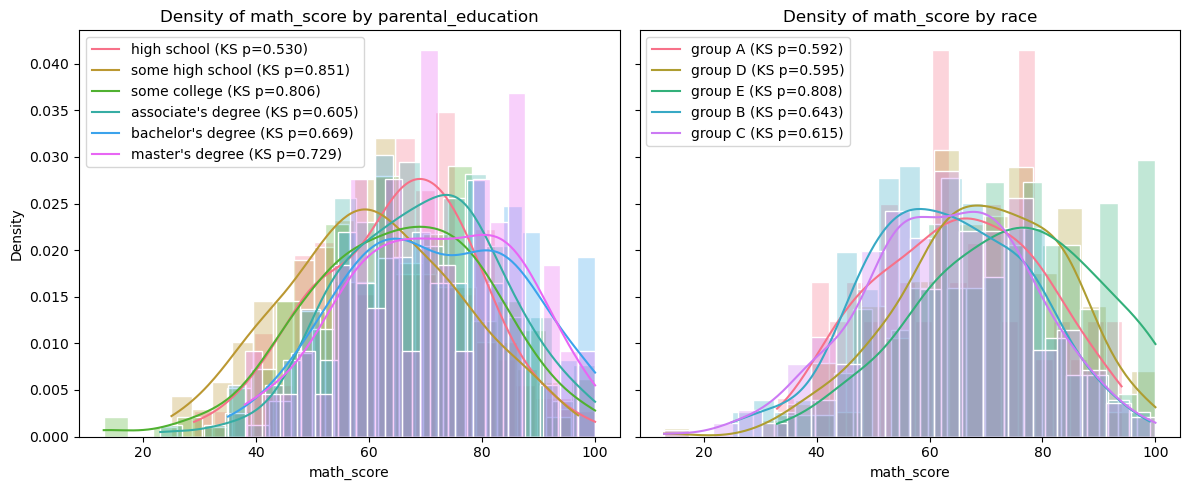

In [104]:
plot_multiple_grouped_distributions(df, ['gender','lunch','course'], 'math_score')
plot_multiple_grouped_distributions(df, ['parental_education','race'], 'math_score')

We can see that male students tend to have better scores in math which I will also support with PCA below. We alo see course interaction with math scores and lunch interaction with it. It will be also discussed during PCA.


Statistical Independence Matrix for gender:
+--------+--------+----------+
|        | male   | female   |
+========+========+==========+
| male   | Yes    | No       |
+--------+--------+----------+
| female | No     | Yes      |
+--------+--------+----------+

Statistical Independence Matrix for lunch:
+--------------+------------+----------------+
|              | standard   | free/reduced   |
+==============+============+================+
| standard     | Yes        | No             |
+--------------+------------+----------------+
| free/reduced | No         | Yes            |
+--------------+------------+----------------+

Statistical Independence Matrix for course:
+-----------+-------------+--------+
|           | completed   | none   |
+===========+=============+========+
| completed | Yes         | No     |
+-----------+-------------+--------+
| none      | No          | Yes    |
+-----------+-------------+--------+


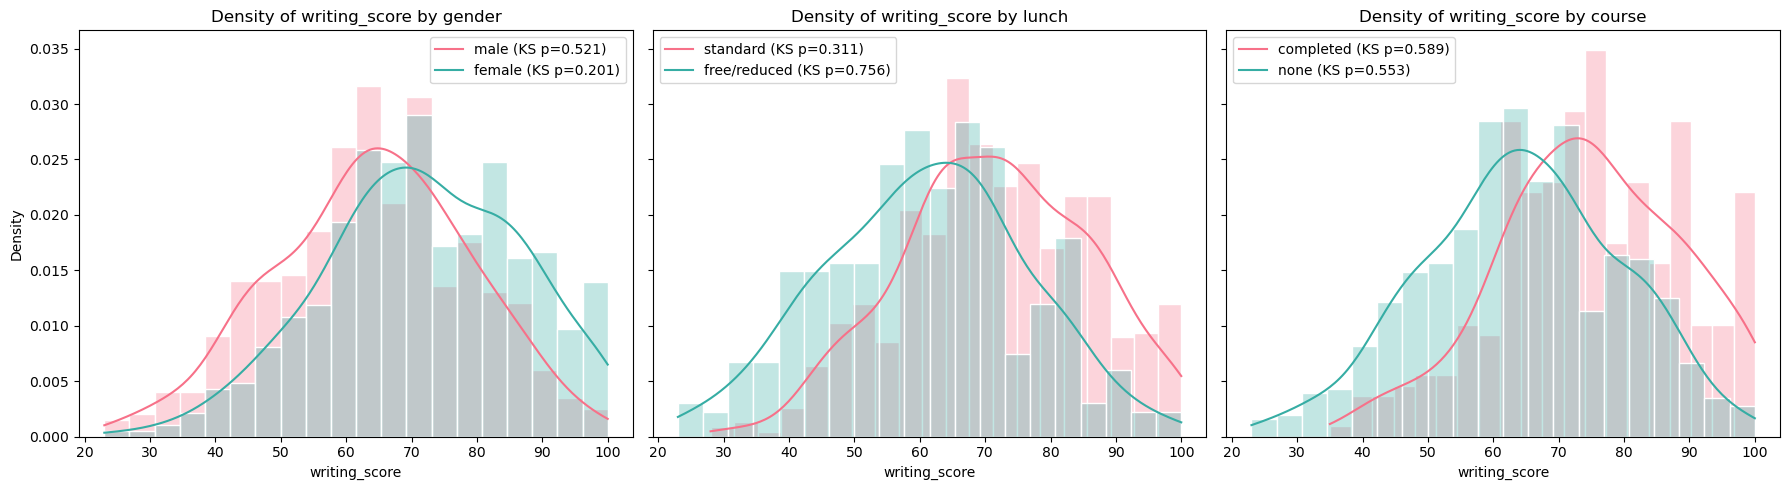


Statistical Independence Matrix for parental_education:
+--------------------+---------------+--------------------+----------------+----------------------+---------------------+-------------------+
|                    | high school   | some high school   | some college   | associate's degree   | bachelor's degree   | master's degree   |
+====================+===============+====================+================+======================+=====================+===================+
| high school        | Yes           | Yes                | Yes            | No                   | No                  | No                |
+--------------------+---------------+--------------------+----------------+----------------------+---------------------+-------------------+
| some high school   | Yes           | Yes                | No             | No                   | No                  | No                |
+--------------------+---------------+--------------------+----------------+---------------

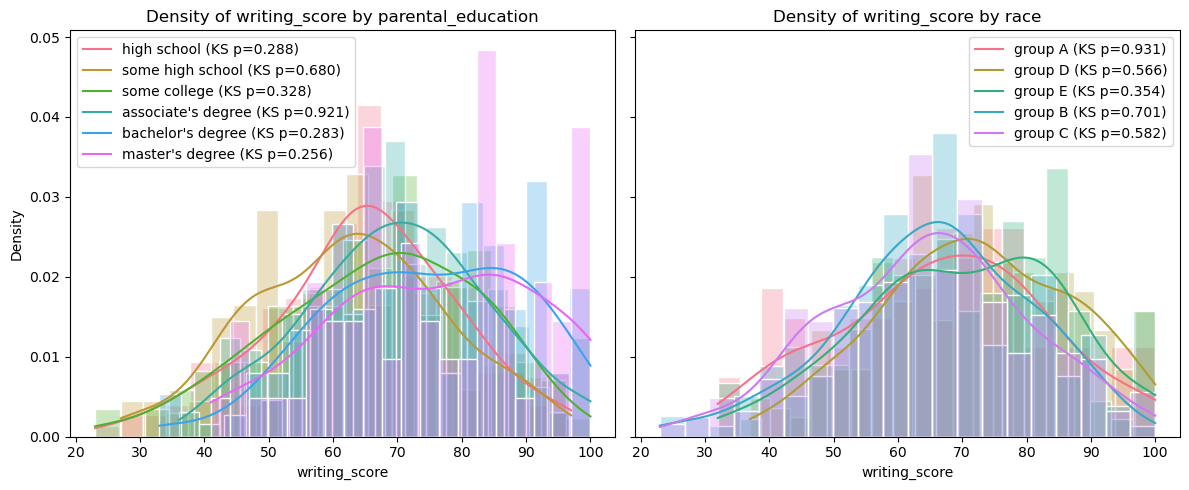

In [107]:
plot_multiple_grouped_distributions(df, ['gender','lunch','course'], 'writing_score')
plot_multiple_grouped_distributions(df, ['parental_education','race'], 'writing_score')

Here we can see that female outperform male students in writing. We can also see how parental education and completed course seems to be more important than in context of math exams.


Statistical Independence Matrix for gender:
+--------+--------+----------+
|        | male   | female   |
+========+========+==========+
| male   | Yes    | No       |
+--------+--------+----------+
| female | No     | Yes      |
+--------+--------+----------+

Statistical Independence Matrix for lunch:
+--------------+------------+----------------+
|              | standard   | free/reduced   |
+==============+============+================+
| standard     | Yes        | No             |
+--------------+------------+----------------+
| free/reduced | No         | Yes            |
+--------------+------------+----------------+

Statistical Independence Matrix for course:
+-----------+-------------+--------+
|           | completed   | none   |
+===========+=============+========+
| completed | Yes         | No     |
+-----------+-------------+--------+
| none      | No          | Yes    |
+-----------+-------------+--------+


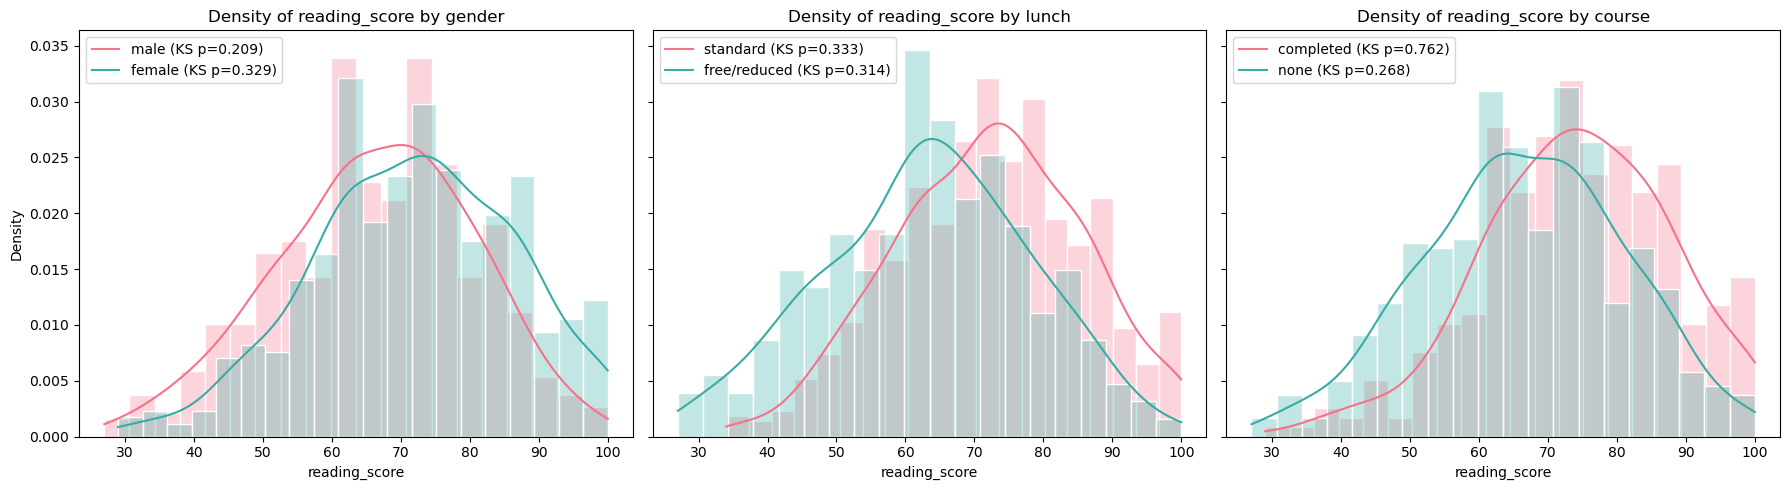


Statistical Independence Matrix for parental_education:
+--------------------+---------------+--------------------+----------------+----------------------+---------------------+-------------------+
|                    | high school   | some high school   | some college   | associate's degree   | bachelor's degree   | master's degree   |
+====================+===============+====================+================+======================+=====================+===================+
| high school        | Yes           | No                 | Yes            | No                   | No                  | No                |
+--------------------+---------------+--------------------+----------------+----------------------+---------------------+-------------------+
| some high school   | No            | Yes                | No             | No                   | No                  | No                |
+--------------------+---------------+--------------------+----------------+---------------

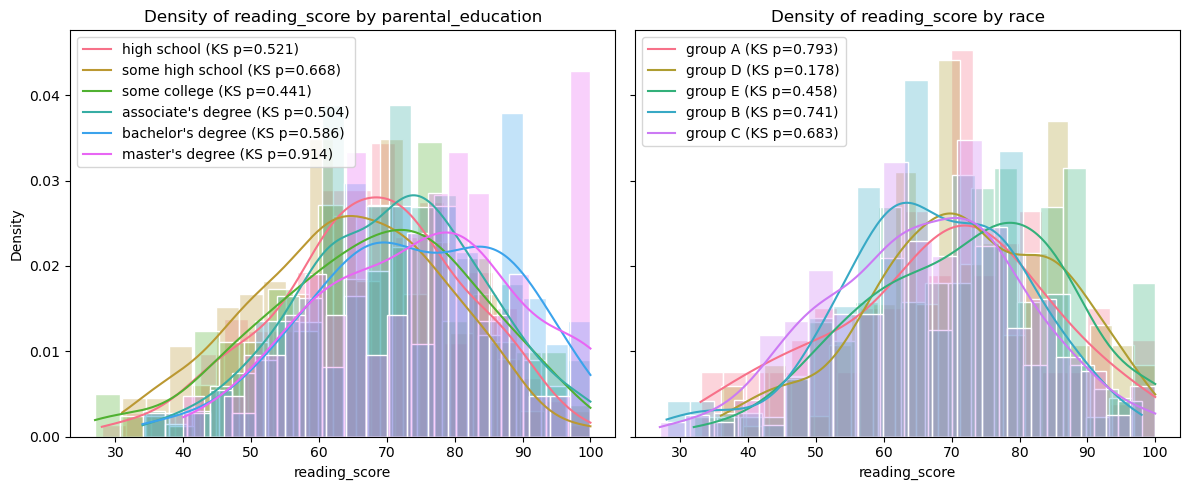

In [117]:
plot_multiple_grouped_distributions(df, ['gender','lunch','course'], 'reading_score')
plot_multiple_grouped_distributions(df, ['parental_education','race'], 'reading_score')

Here again we can see female students having betters scores in humanities. 

Overall we could see that not every groups distributions are statistically different from each other. However we don't see anything really interesting here. The most interesting phenomenon is probably the divide in math scores into two statistically different (but the same inside them) groups: children whose parents have higher education (associate or higher) and lower. In other subjects we don't see such a strict divide.

The data follow a line in our 3D space (see data visualisation). It is also nice to observe (by manipulating plots above for instance) that data is also somewhat flattened, it does not have polar symmetrcy around main trend line. PCA analysis can help us identify this effects.

In [121]:
#PCA analysis
data = df[['math_score', 'reading_score', 'writing_score']].values

#1) Print the correlation matrix before PCA
corr_matrix_before = np.corrcoef(data, rowvar=False)
print("Correlation Matrix before PCA:")
# The correlation matrix is 3x3, so we use the original column names for both index and columns
print(pd.DataFrame(corr_matrix_before, columns=df.columns[5:-1], index=df.columns[5:-1]))
print("\n")

#2) Center the data by subtracting the mean of each feature
mean = np.mean(data, axis=0)
centered_data = data - mean

#3) Apply PCA to the centered data
pca = PCA(n_components=3)  # Apply PCA to all 3 components
pca.fit(centered_data)

# 4) Print the PCA components 
print("PCA Components (Principal Directions):")
print(pd.DataFrame(pca.components_, columns=df.columns[5:-1], index=[f'PC{i+1}' for i in range(3)]))
print("\n")

#5) Print the explained variance for each principal component
print("Explained Variance Ratio (how much variance each PC explains):")
print(pca.explained_variance_ratio_)
print("\n")

#6) Project the data onto the principal components
transformed_data = pca.transform(centered_data)

#7) Print the correlation matrix after PCA 
corr_matrix_after = np.corrcoef(transformed_data, rowvar=False)
print("Correlation Matrix after PCA (transformed data):")
# The transformed data has 3 components, so we label the correlation matrix accordingly
print(pd.DataFrame(corr_matrix_after, columns=[f'PC{i+1}' for i in range(3)], index=[f'PC{i+1}' for i in range(3)]))
print("\n")

#8)Create an interactive 3D plot
fig = go.Figure()

# Add the original data points as scatter plot
fig.add_trace(go.Scatter3d(
    x=df[df['gender']=='female']['math_score'], 
    y=df[df['gender']=='female']['reading_score'], 
    z=df[df['gender']=="female"]['writing_score'], 
    mode='markers', 
    marker=dict(size=1, color='purple', opacity=0.8),
    name='Females'
))
fig.add_trace(go.Scatter3d(
    x=df[df['gender']=='male']['math_score'], 
    y=df[df['gender']=='male']['reading_score'], 
    z=df[df['gender']=='male']['writing_score'], 
    mode='markers', 
    marker=dict(size=1, color='green', opacity=0.8),
    name='Males'
))
# Add the fitted line (principal component)
line_start = mean - 100 * pca.components_[0]
line_end = mean + 100 * pca.components_[0]  # Extend the line for visualization

fig.add_trace(go.Scatter3d(
    x=[line_start[0], line_end[0]], 
    y=[line_start[1], line_end[1]], 
    z=[line_start[2], line_end[2]], 
    mode='lines',
    line=dict(color='red', width=4),
    name='First PCA'
))

# Add the fitted line (principal component)
line_start2 = mean - 100 * pca.components_[1]
line_end2 = mean + 100 * pca.components_[1]  # Extend the line for visualization

fig.add_trace(go.Scatter3d(
    x=[line_start2[0], line_end2[0]], 
    y=[line_start2[1], line_end2[1]], 
    z=[line_start2[2], line_end2[2]], 
    mode='lines',
    line=dict(color='black', width=4),
    name='Second PCA'
))
# Update layout for better visualization
fig.update_layout(
    scene=dict(
        xaxis_title='Math Score',
        yaxis_title='Reading Score',
        zaxis_title='Writing Score',
    ),
    title='PCA: Fitting a Line to 3D Data',
    showlegend=True
)

# Show the interactive plot
fig.show()

print(pca.components_[0])


Correlation Matrix before PCA:
               math_score  reading_score  writing_score
math_score       1.000000       0.819398       0.805944
reading_score    0.819398       1.000000       0.954274
writing_score    0.805944       0.954274       1.000000


PCA Components (Principal Directions):
     math_score  reading_score  writing_score
PC1    0.561946       0.568897       0.600477
PC2    0.826154      -0.349972      -0.441576
PC3   -0.041061       0.744228      -0.666662


Explained Variance Ratio (how much variance each PC explains):
[0.90638122 0.07873124 0.01488754]


Correlation Matrix after PCA (transformed data):
              PC1           PC2           PC3
PC1  1.000000e+00 -5.540830e-16  9.612200e-17
PC2 -5.540830e-16  1.000000e+00 -1.684737e-15
PC3  9.612200e-17 -1.684737e-15  1.000000e+00




[0.56194643 0.56889729 0.60047655]


On the plots above we see that the distribution of our data is mainly driven by two factors. The first and obvious one (responsible for 90% of variation) is the fact that better students will tend to write all exams better. Thats why our data seems so linear. The second and far more interesting factor (resonsible for 14% of variation) is the gender of examined students. This effect is seen as variation along axis defined by PCA2 vector  [0.83, -0.34, -0.44]. We can see that that axis is somewhat math-humanities axis and data points of male students are shifted towards higher math scores and female student's data points are shifted towards better humanities scores. It's not a suprising effect but it is pretty interesting to notice it here graphically.

Normality Test Results (SW or KS):
Female PC2: Test used = KS, p-value = 0.57669
Male PC2: Test used = KS, p-value = 0.46856
Female PC3: Test used = KS, p-value = 0.82903
Male PC3: Test used = KS, p-value = 0.69034
T-test for PC2: t-stat = -30.71486, p-value = 0.00000
T-test for PC3: t-stat = 10.65134, p-value = 0.00000


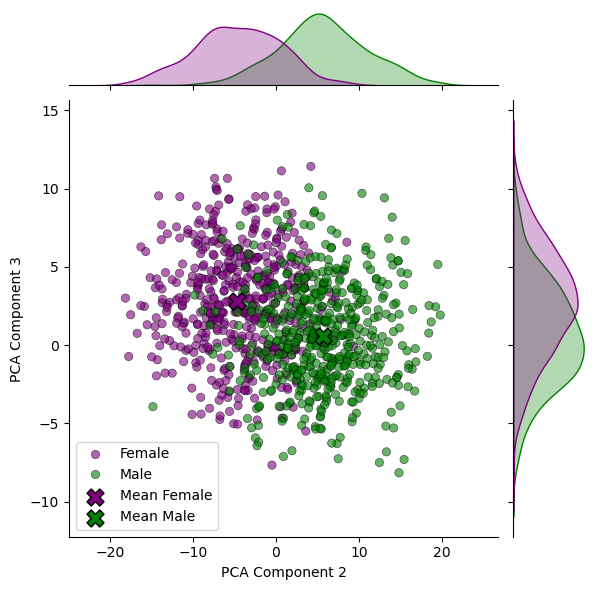

In [127]:
# Extract relevant scores and perform PCA transformation
dvf = df[df['gender'] == 'female'][['math_score', 'writing_score', 'reading_score']].to_numpy()
dvm = df[df['gender'] == 'male'][['math_score', 'writing_score', 'reading_score']].to_numpy()

S = np.linalg.inv(pca.components_.T)

dvfpca = np.dot(dvf, S.T)  # Transform female scores
dvmpca = np.dot(dvm, S.T)  # Transform male scores

# Convert to DataFrame for Seaborn
df_female = pd.DataFrame(dvfpca, columns=["PC1", "PC2", "PC3"])
df_female["Gender"] = "Female"

df_male = pd.DataFrame(dvmpca, columns=["PC1", "PC2", "PC3"])
df_male["Gender"] = "Male"

df_pca = pd.concat([df_female, df_male])  # Merge both datasets

# Compute means
mean_female = df_female[["PC2", "PC3"]].mean()
mean_male = df_male[["PC2", "PC3"]].mean()

# Perform Shapiro-Wilk or Kolmogorov-Smirnov normality tests based on sample size
def test_normality(data, group_name):
    n = len(data)
    if n < 50:
        stat, p_value = shapiro(data)
        test_used = "SW"
    else:
        stat, p_value = kstest(data, 'norm', args=(data.mean(), data.std()))
        test_used = "KS"
    return test_used, p_value

# Normality tests for each PCA component
shapiro_pvals = {}
for component in ["PC2", "PC3"]:
    shapiro_pvals[f"Female {component}"] = test_normality(df_female[component], "Female")
    shapiro_pvals[f"Male {component}"] = test_normality(df_male[component], "Male")

# Print test results
print("Normality Test Results (SW or KS):")
for key, (test_used, pval) in shapiro_pvals.items():
    print(f"{key}: Test used = {test_used}, p-value = {pval:.5f}")

# Two-sample t-test for the differences in means of PCA Components
def perform_ttest(group1, group2, component):
    t_stat, p_value = stats.ttest_ind(group1, group2)
    print(f"T-test for {component}: t-stat = {t_stat:.5f}, p-value = {p_value:.5f}")
    return t_stat, p_value

# Perform t-tests for PCA2 and PCA3
t_stat_pc2, p_value_pc2 = perform_ttest(df_female["PC2"], df_male["PC2"], "PC2")
t_stat_pc3, p_value_pc3 = perform_ttest(df_female["PC3"], df_male["PC3"], "PC3")

# Create a seaborn JointGrid for PC2 and PC3
g = sns.JointGrid(data=df_pca, x="PC2", y="PC3", hue="Gender", palette={"Female": "purple", "Male": "green"})

# Scatter plot in the center
g.plot_joint(sns.scatterplot, alpha=0.6, edgecolor="black")

# Plot means on the main scatter plot
g.ax_joint.scatter(mean_female["PC2"], mean_female["PC3"], color="purple", marker="X", s=150, edgecolor="black", label="Mean Female")
g.ax_joint.scatter(mean_male["PC2"], mean_male["PC3"], color="green", marker="X", s=150, edgecolor="black", label="Mean Male")

# KDE marginal distributions
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.3)

# Adjust labels and add legend inside the main plot
g.ax_joint.set_xlabel("PCA Component 2")
g.ax_joint.set_ylabel("PCA Component 3")
g.ax_joint.legend()

# Show plot
plt.show()



We can clearly see on image above that genders are responsible for our PCA2 variation. From normality tests we know that we can treat our data here as normal distributions. Furthermore, independent t-tests tell us that means of this two groups are statistically different. In that analysis I quietly assumed that main PCA factors for both genders are parallel (that analysis maked most sense in that context). Let's check that assumption.

In [130]:
#PCA for female students
data=dvf.copy()
corr_matrix_before = np.corrcoef(data, rowvar=False)
mean = np.mean(data, axis=0)
centered_data = data - mean
pca = PCA(n_components=3)
pca.fit(centered_data)
print("Female Students")
print("PCA Components (Principal Directions):")
print(pd.DataFrame(pca.components_, columns=df.columns[5:-1], index=[f'PC{i+1}' for i in range(3)]))
print("\n")
print("Explained Variance Ratio (how much variance each PC explains):")
print(pca.explained_variance_ratio_)
print("\n")
#PCA for male students
data=dvm.copy()
corr_matrix_before = np.corrcoef(data, rowvar=False)
mean = np.mean(data, axis=0)
centered_data = data - mean
pca = PCA(n_components=3)
pca.fit(centered_data)
print("Male Students")
print("PCA Components (Principal Directions):")
print(pd.DataFrame(pca.components_, columns=df.columns[5:-1], index=[f'PC{i+1}' for i in range(3)]))
print("\n")
print("Explained Variance Ratio (how much variance each PC explains):")
print(pca.explained_variance_ratio_)
print("\n")

Female Students
PCA Components (Principal Directions):
     math_score  reading_score  writing_score
PC1    0.585335       0.585190       0.561191
PC2    0.810405      -0.400894      -0.427232
PC3    0.025034      -0.704866       0.708898


Explained Variance Ratio (how much variance each PC explains):
[0.9467703  0.03781678 0.01541292]


Male Students
PCA Components (Principal Directions):
     math_score  reading_score  writing_score
PC1    0.569137       0.597361       0.565016
PC2    0.819768      -0.358957      -0.446241
PC3   -0.063750       0.717154      -0.693992


Explained Variance Ratio (how much variance each PC explains):
[0.94031465 0.04491785 0.0147675 ]




As we can see all PCA1 vectors are very close to each other, so my assumption is okay.

Normality Test for Female PCA1: Test Used = KS, p-value = 0.50677
Normality Test for Male PCA1: Test Used = KS, p-value = 0.79184

Two-Sample T-Test Results for PCA1:
T-stat = 2.67708, p-value = 0.00755


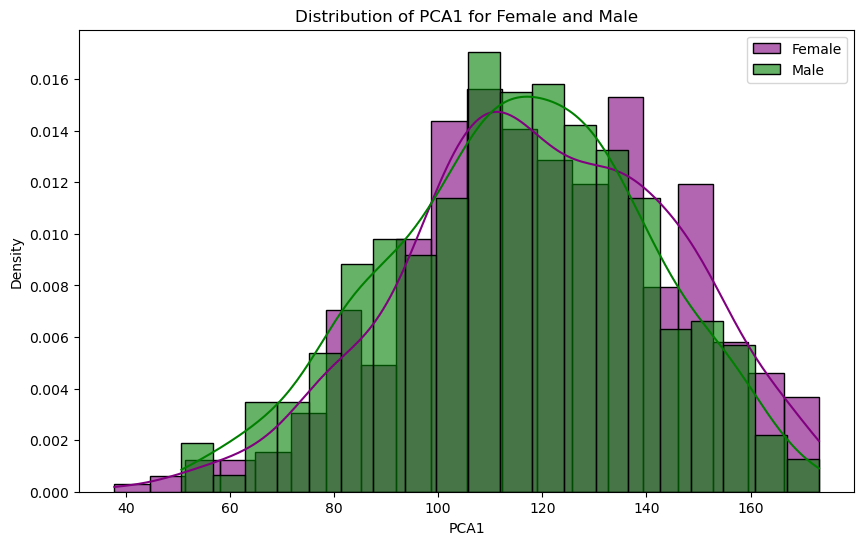

In [133]:
female_pc1 = df_female["PC1"]
male_pc1 = df_male["PC1"]

# Perform normality tests on female and male PCA1 using the pre-defined function
test_used_female, p_value_female = test_normality(female_pc1, "Female")
test_used_male, p_value_male = test_normality(male_pc1, "Male")

# Print normality test results (statistic and p-value)
print(f"Normality Test for Female PCA1: Test Used = {test_used_female}, p-value = {p_value_female:.5f}")
print(f"Normality Test for Male PCA1: Test Used = {test_used_male}, p-value = {p_value_male:.5f}")

# Perform Two-Sample T-Test for PCA1 between female and male
t_stat_pc1, p_value_pc1 = ttest_ind(female_pc1, male_pc1)
print("\nTwo-Sample T-Test Results for PCA1:")
print(f"T-stat = {t_stat_pc1:.5f}, p-value = {p_value_pc1:.5f}")

# Set up the plot
plt.figure(figsize=(10, 6))

# Plot histograms for female and male PCA1
sns.histplot(female_pc1, color="purple", kde=True, stat="density", bins=20, label="Female", alpha=0.6)
sns.histplot(male_pc1, color="green", kde=True, stat="density", bins=20, label="Male", alpha=0.6)

# Add labels and title
plt.title("Distribution of PCA1 for Female and Male")
plt.xlabel("PCA1")
plt.ylabel("Density")
plt.legend()

# Show the plot
plt.show()

From graph inspection we see that gender is not a big factor along PCA axis (which I associate with axis of overall better grades).It is expected as in earlier graphs we saw that average scores are very similar for both genders. We can conduct similiar analysis for other parameters. I will choose lunch and test preparation course.

Normality Test Results (SW or KS):
Standard PC2: Test used = KS, p-value = 0.72539
Reduced PC2: Test used = KS, p-value = 0.42774
Standard PC3: Test used = KS, p-value = 0.57813
Reduced PC3: Test used = KS, p-value = 0.99025
T-test for PC2: t-stat = 4.52481, p-value = 0.00001
T-test for PC3: t-stat = 2.42609, p-value = 0.01544


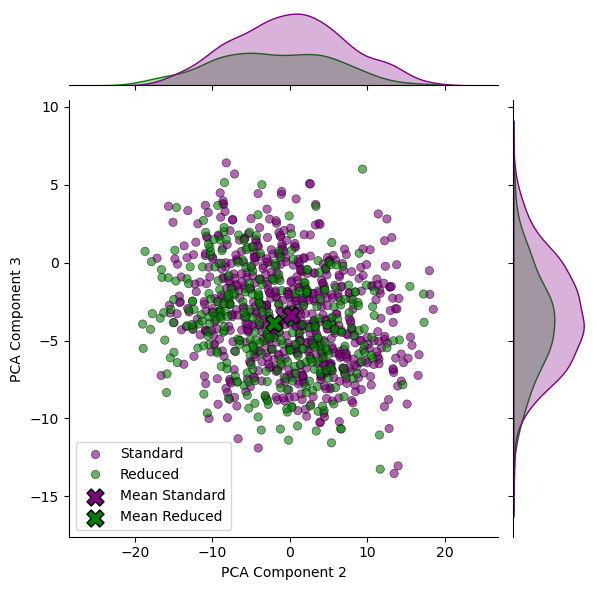


Normality Test Results (SW or KS) for PCA1:
Standard PCA1: Test used = KS, p=0.66418
Reduced PCA1: Test used = KS, p=0.62704
T-test for PCA1: t-stat = 11.58343, p-value = 0.00000


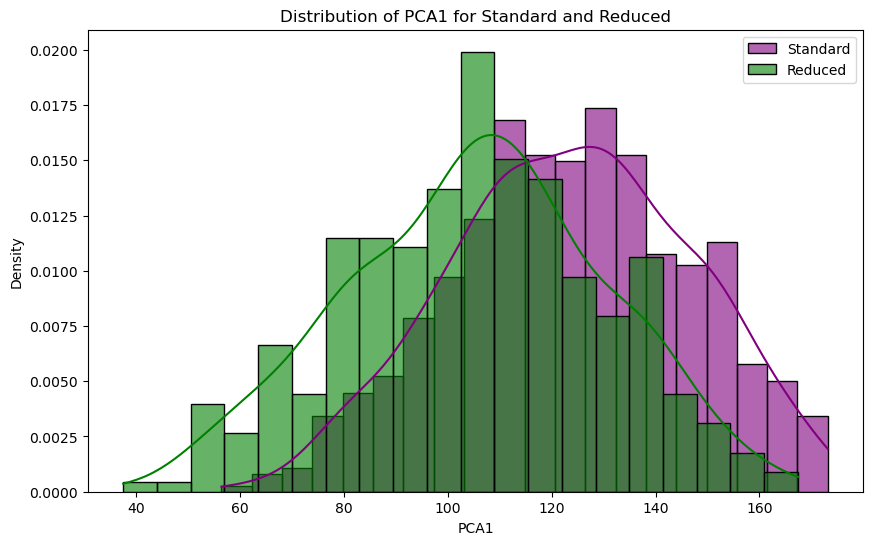

In [136]:
# Extract relevant scores and perform PCA transformation
dvf = df[df['lunch'] == 'standard'][['math_score', 'writing_score', 'reading_score']].to_numpy()
dvm = df[df['lunch'] == 'free/reduced'][['math_score', 'writing_score', 'reading_score']].to_numpy()

S = np.linalg.inv(pca.components_.T)

dvfpca = np.dot(dvf, S.T)  # Transform Standard scores
dvmpca = np.dot(dvm, S.T)  # Transform reduced scores

# Convert to DataFrame for Seaborn
df_st = pd.DataFrame(dvfpca, columns=["PC1", "PC2", "PC3"])
df_st["lunch"] = "Standard"

df_reduced = pd.DataFrame(dvmpca, columns=["PC1", "PC2", "PC3"])
df_reduced["lunch"] = "Reduced"

df_pca = pd.concat([df_st, df_reduced])  # Merge both datasets

# Compute means
mean_st = df_st[["PC2", "PC3"]].mean()
mean_reduced = df_reduced[["PC2", "PC3"]].mean()

# Perform Shapiro-Wilk or Kolmogorov-Smirnov normality tests based on sample size
def test_normality(data, group_name):
    n = len(data)
    if n < 50:
        stat, p_value = shapiro(data)
        test_used = "SW"
    else:
        stat, p_value = kstest(data, 'norm', args=(data.mean(), data.std()))
        test_used = "KS"
    return test_used, p_value

# Normality tests for each PCA component
shapiro_pvals = {}
for component in ["PC2", "PC3"]:
    shapiro_pvals[f"Standard {component}"] = test_normality(df_st[component], "Standard")
    shapiro_pvals[f"Reduced {component}"] = test_normality(df_reduced[component], "Reduced")

# Print test results
print("Normality Test Results (SW or KS):")
for key, (test_used, pval) in shapiro_pvals.items():
    print(f"{key}: Test used = {test_used}, p-value = {pval:.5f}")

# Two-sample t-test for the differences in means of PCA Components
def perform_ttest(group1, group2, component):
    t_stat, p_value = stats.ttest_ind(group1, group2)
    print(f"T-test for {component}: t-stat = {t_stat:.5f}, p-value = {p_value:.5f}")
    return t_stat, p_value

# Perform t-tests for PCA2 and PCA3
t_stat_pc2, p_value_pc2 = perform_ttest(df_st["PC2"], df_reduced["PC2"], "PC2")
t_stat_pc3, p_value_pc3 = perform_ttest(df_st["PC3"], df_reduced["PC3"], "PC3")

# Create a seaborn JointGrid for PC2 and PC3
g = sns.JointGrid(data=df_pca, x="PC2", y="PC3", hue="lunch", palette={"Standard": "purple", "Reduced": "green"})

# Scatter plot in the center
g.plot_joint(sns.scatterplot, alpha=0.6, edgecolor="black")

# Plot means on the main scatter plot
g.ax_joint.scatter(mean_st["PC2"], mean_st["PC3"], color="purple", marker="X", s=150, edgecolor="black", label="Mean Standard")
g.ax_joint.scatter(mean_reduced["PC2"], mean_reduced["PC3"], color="green", marker="X", s=150, edgecolor="black", label="Mean Reduced")

# KDE marginal distributions
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.3)

# Adjust labels and add legend inside the main plot
g.ax_joint.set_xlabel("PCA Component 2")
g.ax_joint.set_ylabel("PCA Component 3")
g.ax_joint.legend()

# Show plot
plt.show()

# Perform normality test for PCA1
shapiro_st_pc1_stat, shapiro_st_pc1_p = test_normality(df_st["PC1"], "Standard")
shapiro_reduced_pc1_stat, shapiro_reduced_pc1_p = test_normality(df_reduced["PC1"], "Reduced")

# Print results
print("\nNormality Test Results (SW or KS) for PCA1:")
print(f"Standard PCA1: Test used = {shapiro_st_pc1_stat}, p={shapiro_st_pc1_p:.5f}")
print(f"Reduced PCA1: Test used = {shapiro_reduced_pc1_stat}, p={shapiro_reduced_pc1_p:.5f}")

# Two-Sample T-Test for PCA1
t_stat_pc1, p_value_pc1 = perform_ttest(df_st["PC1"], df_reduced["PC1"], "PCA1")

# Set up the plot for PCA1
plt.figure(figsize=(10, 6))
# Plot histograms for Standard and Reduced PCA1
sns.histplot(df_st["PC1"], color="purple", kde=True, stat="density", bins=20, label="Standard", alpha=0.6)
sns.histplot(df_reduced["PC1"], color="green", kde=True, stat="density", bins=20, label="Reduced", alpha=0.6)

# Add labels and title
plt.title("Distribution of PCA1 for Standard and Reduced")
plt.xlabel("PCA1")
plt.ylabel("Density")
plt.legend()

# Show the plot
plt.show()


Here we can see that lunch seems to cause variation along PCA1 data not PCA2 or PCA3, which implies that it has an effect on overall performance of students. We can also observe the fact aknowledged earlier: standard lunch seems to increase chances of academic succes.

Normality Test Results (SW or KS):
None course PC2: Test used = KS, p-value = 0.52942
completed PC2: Test used = KS, p-value = 0.44091
None course PC3: Test used = KS, p-value = 0.67056
completed PC3: Test used = KS, p-value = 0.53242
T-test for PC2: t-stat = 6.40574, p-value = 0.00000
T-test for PC3: t-stat = -8.59656, p-value = 0.00000


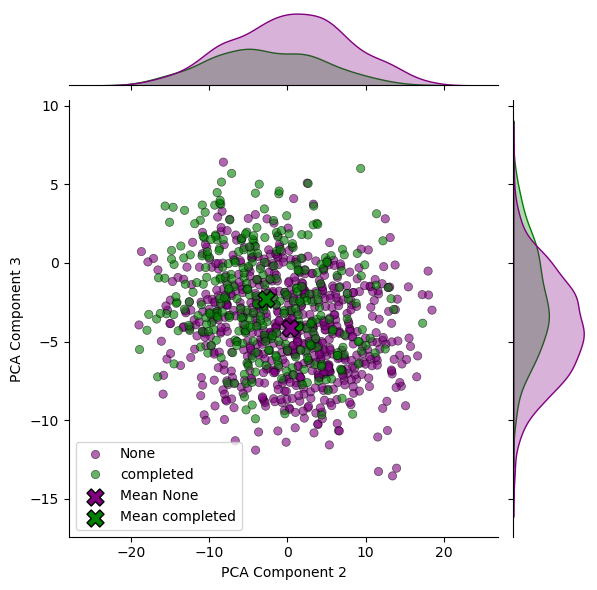


Normality Test Results (SW or KS) for PCA1:
None PCA1: Test used = KS, p=0.82179
Completed PCA1: Test used = KS, p=0.77086
T-test for PCA1: t-stat = -8.19171, p-value = 0.00000


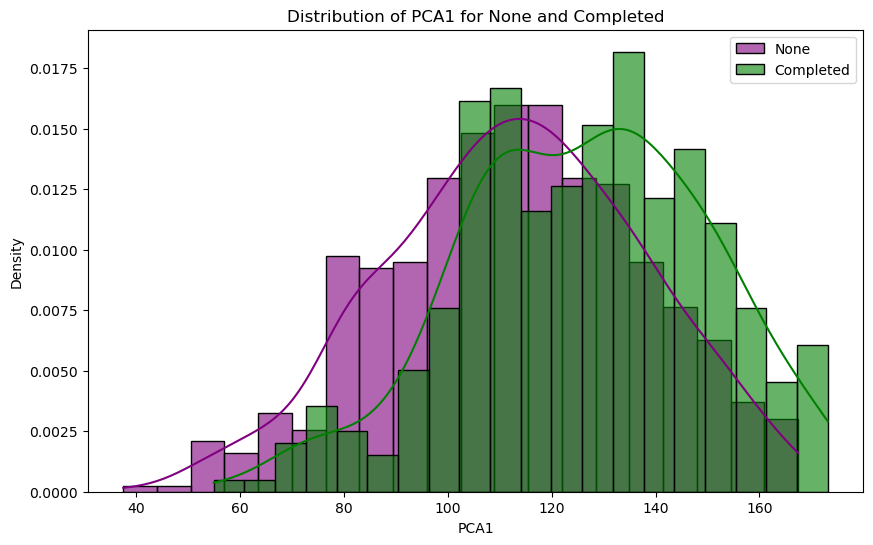

In [138]:
# Extract relevant scores and perform PCA transformation
dvf = df[df['course'] == 'none'][['math_score', 'writing_score', 'reading_score']].to_numpy()
dvm = df[df['course'] == 'completed'][['math_score', 'writing_score', 'reading_score']].to_numpy()

S = np.linalg.inv(pca.components_.T)

dvfpca = np.dot(dvf, S.T)  # Transform None scores
dvmpca = np.dot(dvm, S.T)  # Transform completed scores

# Convert to DataFrame for Seaborn
df_None = pd.DataFrame(dvfpca, columns=["PC1", "PC2", "PC3"])
df_None["course"] = "None"

df_completed = pd.DataFrame(dvmpca, columns=["PC1", "PC2", "PC3"])
df_completed["course"] = "completed"

df_pca = pd.concat([df_None, df_completed])  # Merge both datasets

# Compute means
mean_None = df_None[["PC2", "PC3"]].mean()
mean_completed = df_completed[["PC2", "PC3"]].mean()


# Normality tests for each PCA component
shapiro_pvals = {}
for component in ["PC2", "PC3"]:
    shapiro_pvals[f"None course {component}"] = test_normality(df_None[component], "None")
    shapiro_pvals[f"completed {component}"] = test_normality(df_completed[component], "completed")

# Print test results
print("Normality Test Results (SW or KS):")
for key, (test_used, pval) in shapiro_pvals.items():
    print(f"{key}: Test used = {test_used}, p-value = {pval:.5f}")


# Perform t-tests for PCA2 and PCA3
t_stat_pc2, p_value_pc2 = perform_ttest(df_None["PC2"], df_completed["PC2"], "PC2")
t_stat_pc3, p_value_pc3 = perform_ttest(df_None["PC3"], df_completed["PC3"], "PC3")

# Create a seaborn JointGrid for PC2 and PC3
g = sns.JointGrid(data=df_pca, x="PC2", y="PC3", hue="course", palette={"None": "purple", "completed": "green"})

# Scatter plot in the center
g.plot_joint(sns.scatterplot, alpha=0.6, edgecolor="black")

# Plot means on the main scatter plot
g.ax_joint.scatter(mean_None["PC2"], mean_None["PC3"], color="purple", marker="X", s=150, edgecolor="black", label="Mean None")
g.ax_joint.scatter(mean_completed["PC2"], mean_completed["PC3"], color="green", marker="X", s=150, edgecolor="black", label="Mean completed")

# KDE marginal distributions
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.3)

# Adjust labels and add legend inside the main plot
g.ax_joint.set_xlabel("PCA Component 2")
g.ax_joint.set_ylabel("PCA Component 3")
g.ax_joint.legend()

# Show plot
plt.show()

# Perform normality test for PCA1
shapiro_None_pc1_stat, shapiro_None_pc1_p = test_normality(df_None["PC1"], "None")
shapiro_completed_pc1_stat, shapiro_completed_pc1_p = test_normality(df_completed["PC1"], "completed")

# Print results
print("\nNormality Test Results (SW or KS) for PCA1:")
print(f"None PCA1: Test used = {shapiro_None_pc1_stat}, p={shapiro_None_pc1_p:.5f}")
print(f"Completed PCA1: Test used = {shapiro_completed_pc1_stat}, p={shapiro_completed_pc1_p:.5f}")

# Two-Sample T-Test for PCA1
t_stat_pc1, p_value_pc1 = perform_ttest(df_None["PC1"], df_completed["PC1"], "PCA1")

# Set up the plot for PCA1
plt.figure(figsize=(10, 6))
# Plot histograms for None and completed PCA1
sns.histplot(df_None["PC1"], color="purple", kde=True, stat="density", bins=20, label="None", alpha=0.6)
sns.histplot(df_completed["PC1"], color="green", kde=True, stat="density", bins=20, label="Completed", alpha=0.6)

# Add labels and title
plt.title("Distribution of PCA1 for None and Completed")
plt.xlabel("PCA1")
plt.ylabel("Density")
plt.legend()

# Show the plot
plt.show()

So first of all we can see that there seems to be an difference in PCA3 and PCA2 components for for groups with different course completion status . This effect seems to happen to the same extent on both PCA2 and PCA3 axis which makes it different from gender effect. It's also worth to note that completion of the test correlates with higher scores.

Here I think it is important why I'm using only PCA analysis without varimax. It's because my data is 3dimensional so it's easy to imagine it geometrically.

In this analasysis I explored parameters impact on overall variations of scores and interaction between them. All paraneters seen to have an impact on our final score (see one-way ANOVA). I also explored stasticial differences between all possible subgroups grouped by value of each parameter. With that I was able to gain intuition about my data and notice the fact that parental education of associative degree or higher seems to improve students chances at math exams. I also aknowledged the correlation between the scores and lunch. I also found out that test-preparation course seems to be more important for humantities exams than math ones. The paramaters seem to not interact with each other (see two way ANOVA).
I also gained visual intuition into data using 3D interactive plots and PCA analysis. Subseqent analysis identified main factors driving variations in our data distributions. 